# Rods only — the bending floor

**FormaBonum / analysis** · companion to `Manifesto.md`, *Analytical part*

## 1. Why start with the rods

In a wing, bending is the load that sizes the structure, and **the rods are what carries it**. That
is the point of the whole construction method: pultruded carbon placed as close to the skin as the
print allows, because in bending the only thing that matters as much as how much material you have
is how far it sits from the neutral axis.

The rods do two other useful things. They pin the print together across the layer boundaries, and
they let us build **along the span**, standing the sections on end — normally the weakest direction
for a printed part, here the reinforced one. But those are consequences. The job is to act as
**distributed spars**: instead of one hollow tube sitting near mid-depth because that is where a
tube fits, we get a dozen small rods placed where a spar cap would want to be.

The plastic is not idle — it holds the shape, carries the shear between the rods, stabilises them,
and adds real stiffness of its own. This notebook simply refuses to count that last part, and asks
what the rods alone are worth.

## 2. The wing we will use

Everything below runs on the demo panel this repo carries, `definitions/mk2/`. It is a small UAV
wing, not a special case built to flatter the method, and it is the same definition the builder
turns into printable sections — so the rod positions here are the rod positions that get printed.
Section 3 takes a simplified, straight version of it; section 4 onwards uses the real thing.

NACA 4412 · 800 mm semi-span panel (1600 mm full span) · 200 → 160 mm chord · 20 rods of 3 mm,
spent **5 / 3 / 1 / 1 pairs** over four 200 mm rod spans · panel ≈ 450 g.

Each rod span overlaps its neighbour by 25 mm at each end, so rods hand load over to each other
through a lap rather than butting. That detail turns out to matter more than anything else in the
layout, and §6 shows why.

![mk2 planform](../definitions/mk2/planform.png)

The top panel is what we care about: rods drawn where they physically run, five pairs at the root
thinning to one at the tip. The bottom-left section view shows the pairs sitting just under the
skin, above and below a neutral axis at +6.9 mm.

In [1]:
## Some helper functions for geometry definitions and plots.

from __future__ import annotations

import importlib.util
import math
import pathlib
import sys
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white", "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold",
})
ROD, MED, WARN = "#1b3a6b", "#c2703d", "#b3283c"

G = 9.81                      # m/s^2.  Lengths are mm, forces N, stresses MPa throughout.

# repo root, so `wing_assembler` and `definitions/` are importable from analysis/
ROOT = next(p for p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents)
            if (p / "wing_assembler").is_dir())
sys.path.insert(0, str(ROOT))

from wing_assembler.section_layout import _compute_physical_rod_sections


def load_wing(path="definitions/mk2/wing_definition_mk2.py"):
    """The WingDefinition the builder uses - same file, same object."""
    spec = importlib.util.spec_from_file_location("_wing_def", ROOT / path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod.wing


def rod_spans(wing):
    """[(z_start, z_end, [(y_upper, y_lower), ...]), ...] - where the rods actually are.

    Straight from `wing_assembler`'s own layout pass, so collisions, taper and the
    rod cut-offs are whatever gets printed. Rod heights are constant along a span."""
    out = []
    for ps in _compute_physical_rod_sections(wing):
        if not ps.rods:
            continue
        z1 = min(ps.z_bounds_end, min(r.z_cut_off for r in ps.rods))
        out.append((ps.z_bounds_start, z1, [(r.abs_yu, r.abs_yl) for r in ps.rods]))
    return out


wing  = load_wing()
SPANS = rod_spans(wing)

## 3. First pass: the simplest version of this wing

Take mk2's **root section**: NACA 4412 at 200 mm chord, five rod pairs just under the skin, and extrude it into a straight
1 metre cantilever, with the rods running the **full length, uncut**. No taper, no rod ladder, no
joints.

A single $EI$ for the whole beam is exact rather than an approximation. Everything here is two lines of arithmetic. This is why we start with this case.

We can approach this initial calculation in a conservative, and slightly naive manner by thinking
of the rods as forming an I beam profile, and considering the plastic media as carrying the
entire shear loading perfectly.

This idealized model gives us a good floor for estimating the deflection, getting an idea of how
much reinforcement and where to add it, and most importantly, **we can show how much the simple
rods contribute in this load mode**.

So: treat each rod as a point of area $A$ at height $y$, and the plastic as a perfect shear web
that holds them together and contributes no stiffness of its own.

**Coordinates.** $z$ runs along the beam, from the clamped root ($z = 0$) to the free tip
($z = L$). $y$ is height inside the cross-section, measured up from the airfoil's chord line.
**Units** throughout are mm, N and MPa (1 MPa = 1 N/mm²), so moments come out in N·mm and
bending stiffness in N·mm².

$$ y_{na} = \frac{\sum A\,y}{\sum A} \qquad I = \sum A\,(y - y_{na})^2 \qquad
   M = P L \qquad \sigma = \frac{M\,(y-y_{na})}{I} \qquad \delta = \frac{P L^3}{3EI} $$

* $A$: area of each rod (7.07 mm², $d$ = 3 mm)
* $y$: height of each rod's centre above the chord line
* $y_{na}$: height of the neutral axis (7.50 mm)
* $I$: second moment of area of the rods about the neutral axis (4380 mm⁴)
* $E$: Young's modulus of the rod (125 GPa)
* $P$: tip load
* $L$: beam length (1000 mm)
* $M$: bending moment at the root
* $\sigma$: axial stress in a rod
* $\delta$: tip deflection

For strength we run the chain backwards: set the stress in the
furthest rod to the allowable, $\sigma_{allow}$ = 494 MPa (computed below), and solve for the tip load
that causes it,

$$ P_{max} = \frac{\sigma_{allow}\,I}{\mathrm{arm}\;L} $$

then evaluate $\delta$ at that load. Two notes on what that answer is:

* For a weight hung on the tip, the top rods are in tension and the bottom ones in compression.
  The furthest rod is a bottom one, so checking it against the *compression* allowable is exact.
  Under lift the load reverses, the top rods compress, and their arm is 8.52 mm, so the same
  number is then about 6 % conservative.
* $\delta = PL^3/3EI$ is small-deflection theory, fine while the tip moves under roughly 10 % of
  the length. 
  
Then we do the same sum for a beam of **plastic with no rods at all**, and compare.

In [2]:
@dataclass
class Rods:
    """Everything the model knows about the material."""
    E: float = 125_000.0      # MPa   axial modulus of the pultruded rod
    d_nominal: float = 3.5    # mm    the bore the layout works to
    clearance: float = 0.5    # mm    bore - rod, the glue gap: a 3 mm rod in a 3.5 mm bore
    sigma_c: float = math.nan # MPa   working allowable in compression - NOT a
                              #       property of the carbon, set by rod_buckling() below

    @property
    def d(self) -> float:  return self.d_nominal - self.clearance
    @property
    def A(self) -> float:  return math.pi * (self.d / 2) ** 2          # mm^2
    @property
    def I(self) -> float:  return math.pi * (self.d / 2) ** 4 / 4      # mm^4, one rod's own


rods = Rods(d_nominal=wing.rod_diameter)
print(f"rod   d = {rods.d:.2f} mm    A = {rods.A:.2f} mm^2    E = {rods.E/1000:.0f} GPa"
      f"    EA = {rods.E*rods.A/1000:.0f} kN")

rod   d = 3.00 mm    A = 7.07 mm^2    E = 125 GPa    EA = 884 kN


### What a rod is actually good for

Numbers for standard-modulus pultruded carbon rod — the cheap, everywhere-available stock this
method is built around.

| | value | note |
|---|---|---|
| modulus $E$ | 120–135 GPa | standard-modulus pultrusion. High-modulus stock reaches 200–350 GPa, at a price and with less strain to failure |
| tensile strength | ≥ 1500 MPa | never governs. Nothing in this project has broken a rod in tension |
| compressive strength, raw | ~1000 MPa | the material on its own, if nothing buckles first |
| **working allowable, compression** | **494 MPa** | buckling sideways into the infill, computed below |

Compression is the side that governs. A slender rod pushed hard enough does not crush, it bows
sideways, and the only thing stopping it is the printed infill gripping it along its whole length.
So the allowable is a question about the *plastic*, not the carbon. We treat the rod as a **beam on
an elastic foundation**, with the infill as the foundation:

$$ \sigma_{cr} = \frac{2\sqrt{E I_r\,k}}{A}, \qquad
   k = \frac{0.65\,d\,E_{in}}{1-\nu^2}\left(\frac{E_{in}\,d^4}{E I_r}\right)^{1/12} $$

* $E$, $A$, $d$: rod modulus, area and diameter
* $I_r$: the rod's own second moment of area, $\pi d^4/64$
* $k$: foundation stiffness, the sideways force per mm of rod per mm of deflection (N/mm²), from
  Vesić's solution for a beam resting on an elastic solid [5]
* $E_{in}$, $\nu$: modulus and Poisson ratio of the infill

This is the model `tests/experiment-03` uses, with the same inputs. The infill is the **5 %** the
wing is actually printed at, and its modulus is the Gibson–Ashby estimate $E_{in} = E_s\rho^2$ = 5 MPa.

That choice runs the opposite way to §3's plastic beam, on purpose. There, stiffer infill helps the
plastic, so we took the upper bound. Here, stiffer infill helps the rod, so we take the low estimate.
Both choices go against the rods. 

For a lower limit, `tests/experiment-01` held 80 kgf with its worst rod at 282 MPa, so a real
allowable cannot be below that. Everything below scales linearly with the allowable, so if you
disagree with 494, scale the answers.

Worth noting that this is the mode that actually fails in the successful builds. The ellipse test that started this project
broke the **rods, in compression** — the plastic and the glue held.

<sub>[5] A. S. Vesić, *Bending of beams resting on isotropic elastic solid*, J. Eng. Mech. Div. ASCE
87 (EM2) (1961) 35–53.</sub>

In [3]:
# ── rod compressive allowable: buckling sideways into the infill ─────────────
E_PRINT, RHO_PRINT, NU_PRINT = 2_000.0, 0.05, 0.35   # MPa, solid fraction, -  (as printed)


def rod_buckling(rods, E_s=E_PRINT, rho=RHO_PRINT, nu=NU_PRINT):
    """Axial stress at which a rod buckles into the infill: beam on an elastic foundation,
    P_cr = 2 sqrt(EI k), with Vesic's k and a Gibson-Ashby infill modulus E_s rho^2."""
    E_in = E_s * rho ** 2
    EI = rods.E * rods.I
    k = 0.65 * rods.d * E_in / (1 - nu ** 2) * (E_in * rods.d ** 4 / EI) ** (1 / 12)
    return 2 * math.sqrt(EI * k) / rods.A


rods.sigma_c = rod_buckling(rods)
print(f"infill {100*RHO_PRINT:.0f} % -> E_in = {E_PRINT*RHO_PRINT**2:.0f} MPa    "
      f"rod buckles at sigma_c = {rods.sigma_c:.0f} MPa")

infill 5 % -> E_in = 5 MPa    rod buckles at sigma_c = 494 MPa


In [4]:
# ── the straight test beam: mk2's root section, extruded 1 m ────────────────
from wing_assembler.naca import naca4_polygon_pts, offset_polygon, rod_y_upper, rod_y_lower

NACA, CHORD, L_BEAM = wing.naca, wing.root_chord, 1000.0
SKIN = wing.skin_distance                     # mm, rod surface to skin
X_MID, HALF_PITCH = -30.0, 6.52               # mk2's rod lattice, in mm from mid-chord

pcts = [(X_MID + HALF_PITCH * j) / CHORD + 0.5 for j in (-4, -2, 0, 2, 4)]
y_b = np.array([f(NACA, p, CHORD, SKIN, wing.rod_diameter / 2)
                for p in pcts for f in (rod_y_upper, rod_y_lower)])

yna_b = y_b.mean()                            # equal areas -> plain average
I_b   = rods.A * np.sum((y_b - yna_b) ** 2)   # sum A d^2
EI_b  = rods.E * I_b
arm_b = np.max(np.abs(y_b - yna_b))

print(f"{NACA} at {CHORD:.0f} mm chord, {L_BEAM:.0f} mm long, {y_b.size} rods running uncut\n")
print(f"rod heights       " + "  ".join(f"{v:+.1f}" for v in sorted(y_b, reverse=True)))
print(f"neutral axis      y_na  = {yna_b:.2f} mm")
print(f"second moment     I     = {I_b:.0f} mm^4")
print(f"bending stiffness EI    = {EI_b/1e9:.3f}e9 N.mm^2")
print(f"worst lever arm   arm   = {arm_b:.2f} mm")

4412 at 200 mm chord, 1000 mm long, 10 rods running uncut

rod heights       +16.0  +15.7  +15.6  +14.9  +14.4  +0.8  +0.3  -0.3  -0.9  -1.6
neutral axis      y_na  = 7.50 mm
second moment     I     = 4380 mm^4
bending stiffness EI    = 0.548e9 N.mm^2
worst lever arm   arm   = 9.05 mm


In [5]:
def cantilever(EI, I_sec, arm, E_mat, sigma_allow, L=L_BEAM):
    """Max tip load a constant-section cantilever takes, and how far it bends there."""
    P_max = sigma_allow * I_sec / (arm * L)          # from sigma = P L arm / I
    return dict(P=P_max, kgf=P_max / G, delta=P_max * L ** 3 / (3 * EI),
                EI=EI, I=I_sec, arm=arm, E=E_mat, sigma=sigma_allow)


beam_rods = cantilever(EI_b, I_b, arm_b, rods.E, rods.sigma_c)

print(f"rods only, {L_BEAM:.0f} mm cantilever, load on the tip\n")
print(f"   max tip load       {beam_rods['P']:7.1f} N  =  {beam_rods['kgf']:.1f} kgf")
print(f"   root moment there  {beam_rods['P']*L_BEAM/1000:7.1f} N.m")
print(f"   tip deflection     {beam_rods['delta']:7.1f} mm  "
      f"({100*beam_rods['delta']/L_BEAM:.0f} % of length)")
print(f"\nTen 3 mm rods - about {y_b.size * rods.A * L_BEAM * 1.6e-3:.0f} g of carbon - hold "
      f"{beam_rods['kgf']:.0f} kg off the end of a metre.")

rods only, 1000 mm cantilever, load on the tip

   max tip load         239.3 N  =  24.4 kgf
   root moment there    239.3 N.m
   tip deflection       145.7 mm  (15 % of length)

Ten 3 mm rods - about 113 g of carbon - hold 24 kg off the end of a metre.


### Now the same beam with no rods at all

Identical outside shape, identical length, but printed plastic only.

This beam is **not a prediction** of what the printed plastic does. It is here for one reason: to
show how completely the rods dominate bending. So every choice below is the most generous to the
plastic we can defend. If the rods still win by a wide margin, the conclusion cannot hinge on print
settings, infill pattern or material data.

* **one wall** of 0.45 mm — the thinnest thing a printer will make, and what the real part uses;
* **10 % infill**, which is roughly double what this wing is actually printed at. Heavier than
  reality, and stiffer;
* **30 MPa allowable**, generous again. A thin printed wall fails by buckling into the infill long
  before the material yields, and at 10 % infill that limit works out near 33 MPa. At the 5 % the
  real wing uses it is closer to 13;
* **infill at the Hashin–Shtrikman upper bound**, the stiffest any isotropic lattice can be.

#### The infill modulus: an upper bound, on purpose

We give the infill the **Hashin–Shtrikman upper bound** for an isotropic porous solid [1]. It is the
tightest limit there is on how stiff a material with voids can be if it is equally stiff in every
direction. At low density it reduces to

$$ E^* \approx \tfrac{1}{2}\,\rho\,E_s $$

where $\rho$ is the solid fraction of the infill (0.10), $E_s$ is the modulus of the plastic it is
made of (2 GPa), and $E^*$ is the modulus the infill behaves as. The ½ barely depends on the
plastic's Poisson ratio. That gives **100 MPa**.

To put that in context, at the same 10 %:

| model | $E^*$ | what it describes |
|---|---|---|
| Gibson–Ashby, $E_s\rho^2$ [3] | 20 MPa | foams and lattices whose struts bend |
| octet truss, $\approx E_s\rho/9$ [4] | 22 MPa | the classic stretch-dominated truss |
| **Hashin–Shtrikman, $\approx E_s\rho/2$** [1] | **100 MPa** | the isotropic limit, reached by plate lattices [2] |

Ordinary slicer infill (gyroid, cubic, rectilinear) sits well below the bound. We are **not**
claiming the printed infill is this stiff. We use the bound *because* it is an overestimate: for any
isotropic infill, the plastic beam below is at least as stiff as the real one, and the rods'
advantage at least as large as shown. For strength it is doubly generous, because infill walls this
thin buckle long before the skin reaches 30 MPa.

The one way to beat the bound is to give up isotropy: straight walls running exactly along the span
can reach $E_s\rho$, twice as much. That would move the ratios below from ×13.6 / ×5.5 to about
×10.8 / ×4.3. The conclusion is the same.

<sub>[1] Z. Hashin & S. Shtrikman, *A variational approach to the theory of the elastic behaviour of
multiphase materials*, J. Mech. Phys. Solids 11 (1963) 127–140.
[2] J. B. Berger, H. N. G. Wadley & R. M. McMeeking, *Mechanical metamaterials at the theoretical
limit of isotropic elastic stiffness*, Nature 543 (2017) 533–537.
[3] L. J. Gibson & M. F. Ashby, *Cellular Solids*, 2nd ed., Cambridge University Press (1997).
[4] V. S. Deshpande, N. A. Fleck & M. F. Ashby, *Effective properties of the octet-truss lattice
material*, J. Mech. Phys. Solids 49 (2001) 1747–1769.</sub>

In [6]:
# ── the same beam in plastic, no rods ────────────────────────────────────────
E_PLASTIC, WALL, INFILL = 2_000.0, 0.45, 0.10       # MPa, mm, solid fraction
SIGMA_PLASTIC = 30.0                                # MPa, generous - see above
E_INFILL = 0.5 * INFILL * E_PLASTIC                 # Hashin-Shtrikman upper bound, low density


def poly(pts):
    """(A, int y dA, int y^2 dA) of a closed polygon, orientation-independent."""
    x = np.asarray([p[0] for p in pts] + [pts[0][0]])
    y = np.asarray([p[1] for p in pts] + [pts[0][1]])
    cr = x[:-1] * y[1:] - x[1:] * y[:-1]
    A = cr.sum() / 2
    Q = (cr * (y[:-1] + y[1:])).sum() / 6
    I = (cr * (y[:-1] ** 2 + y[:-1] * y[1:] + y[1:] ** 2)).sum() / 12
    s = 1.0 if A >= 0 else -1.0
    return A * s, Q * s, I * s


outer, inner = naca4_polygon_pts(NACA, CHORD), offset_polygon(naca4_polygon_pts(NACA, CHORD), WALL)
Ao, Qo, Io = poly(outer)
Ai, Qi, Ii = poly(inner)

# wall at full modulus, interior at the upper-bound infill modulus
terms = [(E_PLASTIC, Ao, Qo, Io), (-E_PLASTIC, Ai, Qi, Ii), (E_INFILL, Ai, Qi, Ii)]
EA = sum(e * a for e, a, _, _ in terms)
yna_p = sum(e * q for e, _, q, _ in terms) / EA
EI_p = sum(e * (i - 2 * yna_p * q + yna_p ** 2 * a) for e, a, q, i in terms)
arm_p = max(max(p[1] for p in outer) - yna_p, yna_p - min(p[1] for p in outer))

beam_plastic = cantilever(EI_p, EI_p / E_PLASTIC, arm_p, E_PLASTIC, SIGMA_PLASTIC)

print(f"wall {WALL} mm at {E_PLASTIC/1000:.0f} GPa, infill {100*INFILL:.0f} % at "
      f"{E_INFILL:.0f} MPa (HS upper bound)   (wall cross-section {Ao-Ai:.0f} mm^2)\n")
print(f"   neutral axis       y_na = {yna_p:.2f} mm      worst arm {arm_p:.2f} mm")
print(f"   bending stiffness  EI   = {EI_p/1e9:.4f}e9 N.mm^2")
print(f"   max tip load       {beam_plastic['P']:7.1f} N  =  {beam_plastic['kgf']:.2f} kgf")
print(f"   tip deflection     {beam_plastic['delta']:7.1f} mm  "
      f"({100*beam_plastic['delta']/L_BEAM:.0f} % of length)")

wall 0.45 mm at 2 GPa, infill 10 % at 100 MPa (HS upper bound)   (wall cross-section 184 mm^2)

   neutral axis       y_na = 5.80 mm      worst arm 13.97 mm
   bending stiffness  EI   = 0.0403e9 N.mm^2
   max tip load          43.2 N  =  4.41 kgf
   tip deflection       357.9 mm  (36 % of length)


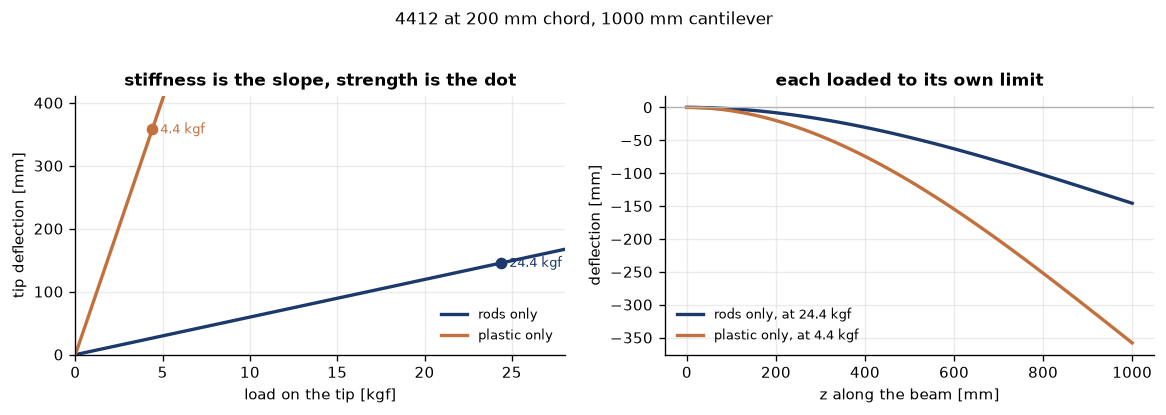

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(9.8, 3.3))

# ── tip load against tip deflection: slope is stiffness, the dot is strength ──
kgf = np.linspace(0, 1.15 * beam_rods["kgf"], 200)
for b, tag, col in ((beam_rods, "rods only", ROD), (beam_plastic, "plastic only", MED)):
    ax[0].plot(kgf, kgf * G * L_BEAM ** 3 / (3 * b["EI"]), color=col, lw=2, label=tag)
    ax[0].plot(b["kgf"], b["delta"], "o", color=col, ms=6)
    ax[0].annotate(f"  {b['kgf']:.1f} kgf", (b["kgf"], b["delta"]), color=col, fontsize=8,
                   va="center")
ax[0].set(xlabel="load on the tip [kgf]", ylabel="tip deflection [mm]",
          title="stiffness is the slope, strength is the dot",
          xlim=(0, kgf[-1]), ylim=(0, 1.15 * beam_plastic["delta"]))
ax[0].legend(frameon=False, fontsize=8, loc="lower right")

# ── deflected shape, each at its own limit ───────────────────────────────────
zb = np.linspace(0, L_BEAM, 120)
for b, tag, col in ((beam_rods, "rods only", ROD), (beam_plastic, "plastic only", MED)):
    shape = b["P"] * zb ** 2 * (3 * L_BEAM - zb) / (6 * b["EI"])
    ax[1].plot(zb, -shape, color=col, lw=2, label=f"{tag}, at {b['kgf']:.1f} kgf")
ax[1].axhline(0, color="0.7", lw=0.8)
ax[1].set(xlabel="z along the beam [mm]", ylabel="deflection [mm]",
          title="each loaded to its own limit")
ax[1].legend(frameon=False, fontsize=8, loc="lower left")

fig.suptitle(f"{NACA} at {CHORD:.0f} mm chord, {L_BEAM:.0f} mm cantilever", fontsize=10, y=1.03)
fig.tight_layout(); plt.show()

In [8]:
r_EI = EI_b / EI_p
r_P  = beam_rods["kgf"] / beam_plastic["kgf"]
print(f"{'':<22}{'EI':>16}{'max tip load':>16}{'deflection there':>20}")
print("-" * 74)
for b, tag in ((beam_rods, "rods only"), (beam_plastic, "plastic only")):
    print(f"{tag:<22}{b['EI']/1e9:>12.4f}e9{b['kgf']:>12.1f} kgf{b['delta']:>17.0f} mm")
print(f"{'ratio':<22}{r_EI:>14.1f} x{r_P:>14.1f} x")
print(f"\nAdding {y_b.size} rods - {y_b.size * rods.A * L_BEAM * 1.6e-3:.0f} g of carbon on a "
      f"{(Ao-Ai) * L_BEAM * 1.24e-3:.0f} g plastic shell - multiplies bending stiffness by "
      f"{r_EI:.1f}\nand the load it carries by {r_P:.1f}, and that is with the plastic given "
      f"the stiffest\nisotropic infill there is, double its real density and more than double its real allowable.")

                                    EI    max tip load    deflection there
--------------------------------------------------------------------------
rods only                   0.5475e9        24.4 kgf              146 mm
plastic only                0.0403e9         4.4 kgf              358 mm
ratio                           13.6 x           5.5 x

Adding 10 rods - 113 g of carbon on a 228 g plastic shell - multiplies bending stiffness by 13.6
and the load it carries by 5.5, and that is with the plastic given the stiffest
isotropic infill there is, double its real density and more than double its real allowable.


### The point of the first pass

Same shape, same length, same printer. The plastic version is a wing you can pick up and bend with
one hand. Add ten 3 mm rods and it carries five and a half times the load and is nearly fourteen times
stiffer — and
that is against plastic given the stiffest isotropic infill physics allows, at double the real
density. The comparison was rigged in the plastic's favour at every step, and the rods still
dominate. Any real infill only widens the gap.

That is the whole thesis of the method in one table. **For this load path the rods are not a
stiffener, they are the structure**, and the plastic's real jobs are the ones this calculation
already assumed for free: hold the shape, carry the shear, keep the rods straight and where they
were put.

It also shows why the rods-only idealization is worth trusting as a floor. If the plastic is worth
at most about 7 % of the bending stiffness, even at the upper bound, then ignoring it entirely costs almost nothing in accuracy and
buys a number that does not depend on print settings at all.

Two things this beam does not have, which the real panel does: **taper**, and rods that **stop and
hand over** rather than running the full length. That is the next section.

## 4. Second pass: section by section

Now the real panel: tapered, and with the rods spent 5 / 3 / 1 / 1 down the span instead of running
the full length. One refinement covers both — evaluate the same two lines of arithmetic at every
station, with whatever rods are actually there, instead of once for the whole beam.

Written out properly, the model is two assumptions:

**A1 — the rods carry all the direct stress.** Each rod is a point of area $A$ at height $y$: a
*boom*. The plastic is given zero stiffness along the span, so it adds nothing to $EI$.

**A2 — the plastic is perfect in shear.** It ties the rods together without distorting, so the
section stays plane as it bends and strain grows linearly with $y$. This is what makes $N$ rods
behave as one beam instead of $N$ separate ones. It is also the assumption that the I-beam picture
in §3 was quietly making.

Everything then follows as an ordinary cantilever, evaluated station by station:

$$ EI(z) = E\sum_i A\,(y_i - y_{na})^2, \qquad
   \kappa = \frac{M}{EI}, \qquad
   \theta = \int_0^z\!\kappa, \qquad
   \delta = \int_0^z\!\theta, \qquad
   \sigma_i = E\,(y_i - y_{na})\,\kappa $$

What changes from §3 is that every quantity is now a function of the span station $z$, and the
tip-load shortcuts ($M = PL$, $\delta = PL^3/3EI$) are replaced by the general route they came from.

| symbol | what it is | units |
|---|---|---|
| $z$ | span station, from the root ($z = 0$) to the tip ($z = s$) | mm |
| $s$ | semi-span, the length of this panel: 800 mm | mm |
| $y_i$ | height of rod $i$, one of the rods present at station $z$ | mm |
| $y_{na}(z)$ | neutral axis at $z$, the mean height of the rods present there | mm |
| $EI(z)$ | bending stiffness at $z$ — changes wherever the rod count changes | N·mm² |
| $M(z)$ | bending moment at $z$: the effect of all the load **outboard** of $z$ | N·mm |
| $\kappa(z)$ | **curvature**, how sharply the beam is bent at $z$ (1 / bend radius) | 1/mm |
| $\theta(z)$ | **slope** of the beam at $z$ (radians, small) | – |
| $\delta(z)$ | **deflection** at $z$; $\delta(s)$ is the tip deflection | mm |
| $\sigma_i(z)$ | axial stress in rod $i$ at $z$ | MPa |

In words:

* **Moment from load.** With a lift distribution $w(z)$ in N/mm (§5) and a possible tip load $P$,
  the shear at $z$ is everything outboard of it, $V(z) = \int_z^s w\,dz' + P$, and the moment is
  that shear summed over its lever arm, $M(z) = \int_z^s V\,dz'$. Both are zero at the tip and
  largest at the root.
* **Curvature from moment.** A section bends in proportion to the moment on it and in inverse
  proportion to its stiffness: $\kappa = M/EI$. A weak station bends sharply even under a modest
  moment.
* **Shape from curvature.** Slope is curvature summed from the root, and deflection is slope summed
  from the root. Both start at zero because the root is clamped: it neither moves nor rotates.
  So a sharp bend near the root tilts everything outboard of it.
* **Stress from curvature.** Strain in a rod is its distance from the neutral axis times the
  curvature, and $\sigma = E \times$ strain. This is the same thing as §3's $M(y-y_{na})/I$, just
  written through $\kappa$. The code keeps only the worst rod, $\sigma = E\,\mathrm{arm}\,\kappa$.

The term that does the work is $A(y_i-y_{na})^2$ — distance from the neutral axis, **squared**. A
3 mm rod 12.5 mm from the neutral axis (a pair 25 mm apart) is worth about 280 times its own
$\pi r^4/4$. That is why we drop each rod's own second moment entirely (about 1 % of the root
$EI$), and why placing carbon near the skin is the whole game.

In [9]:
@dataclass
class Panel:
    """A cantilever half-wing: a span length plus the rod spans that fill it."""
    span: float
    spans: list                          # [(z0, z1, [(y_upper, y_lower), ...]), ...]
    name: str = "panel"

    def booms(self, z: float) -> np.ndarray:
        """Rod heights present at station z."""
        return np.array([v for z0, z1, pairs in self.spans if z0 <= z <= z1
                         for p in pairs for v in p])


def sweep(panel: Panel, rods: Rods, n_pts: int = 241):
    """EI, neutral axis and worst lever arm along the span."""
    z = np.linspace(0.0, panel.span, n_pts)
    EI, y_na, arm, n = [], [], [], []
    for zi in z:
        y = panel.booms(zi)
        if y.size == 0:
            raise ValueError(f"no rods at z = {zi:.0f} mm - nothing to bend. A disposition "
                             "with a bare span needs the full multi-material model.")
        c = y.mean()
        EI.append(rods.E * rods.A * np.sum((y - c) ** 2))
        y_na.append(c); arm.append(np.max(np.abs(y - c))); n.append(y.size)
    return z, np.array(EI), np.array(y_na), np.array(arm), np.array(n)


panel = Panel(wing.span, SPANS, "mk2")
z, EI_z, y_na_z, arm_z, n_z = sweep(panel, rods)

print(f"EI    root {EI_z[0]/1e9:6.3f}    mid {EI_z[len(z)//2]/1e9:6.3f}"
      f"    tip {EI_z[-1]/1e9:6.3f}     (10^9 N.mm^2)")
print(f"\nsection 3's straight beam came out at {EI_b/1e9:.3f}e9 - a little stiffer than this "
      f"wing's root.\nSame five pairs, but there they sit in a full {CHORD:.0f} mm chord the whole "
      f"way, while here the\nfirst span's rods are placed to still fit at its outboard end, where "
      f"the chord has already tapered.")

EI    root  0.459    mid  0.322    tip  0.060     (10^9 N.mm^2)

section 3's straight beam came out at 0.548e9 - a little stiffer than this wing's root.
Same five pairs, but there they sit in a full 200 mm chord the whole way, while here the
first span's rods are placed to still fit at its outboard end, where the chord has already tapered.


In [10]:
def _cum(f, x):
    """Cumulative trapezoid from x[0]."""
    return np.concatenate([[0.0], np.cumsum(np.diff(x) * (f[1:] + f[:-1]) / 2)])


def solve(panel, rods, mass_kg=0.0, n=1.0, lift="elliptical", tip_kg=0.0, n_pts=241):
    """Bend one panel, station by station.

    mass_kg is the whole aircraft and this panel carries half of it, at load factor n.
    tip_kg is a weight hung on this panel's tip, applied in full."""
    z, EI, y_na, arm, _ = sweep(panel, rods, n_pts)
    s = panel.span
    Lift = n * mass_kg * G / 2
    P = n * tip_kg * G
    w = ((4 * Lift / (math.pi * s)) * np.sqrt(np.clip(1 - (z / s) ** 2, 0, 1))
         if lift == "elliptical" else np.full_like(z, Lift / s))

    V = _cum(w, z)[-1] - _cum(w, z) + P          # shear  = int_z^s w + P
    M = _cum(V, z)[-1] - _cum(V, z)              # moment = int_z^s V

    kappa = M / EI
    theta = _cum(kappa, z)                       # slope, zero at the fixed root
    delta = _cum(theta, z)                       # deflection
    sigma = rods.E * arm * kappa                 # worst rod stress at each station
    return dict(z=z, EI=EI, y_na=y_na, arm=arm, w=w, V=V, M=M, kappa=kappa,
                theta=theta, delta=delta, sigma=sigma, lift=Lift, P=P)

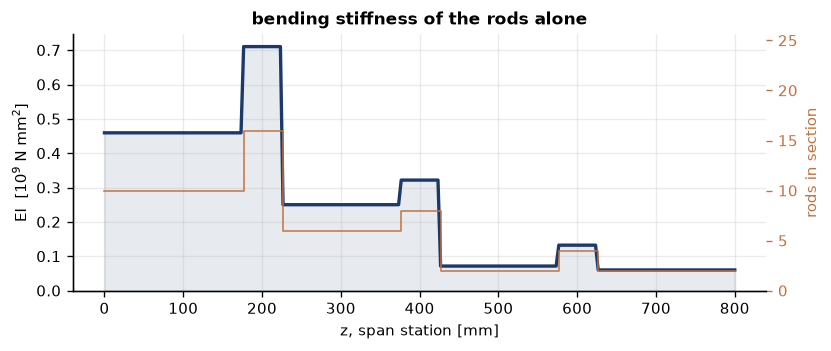

In [11]:
fig, ax = plt.subplots(figsize=(7.0, 3.0))

ax.plot(z, EI_z / 1e9, color=ROD, lw=2)
ax.fill_between(z, 0, EI_z / 1e9, color=ROD, alpha=0.10)
ax.set(xlabel="z, span station [mm]", ylabel="EI  [10$^9$ N mm$^2$]",
       title="bending stiffness of the rods alone", ylim=(0, None))

axr = ax.twinx()
axr.step(z, n_z, where="post", color=MED, lw=1.0, alpha=0.9)
axr.set_ylabel("rods in section", color=MED)
axr.tick_params(colors=MED); axr.grid(False); axr.set_ylim(0, n_z.max() * 1.6)

fig.tight_layout(); plt.show()

Two things in that trace matter.

**The spikes are the laps.** Where two rod spans overlap, both sets of rods are in the section at
once and $EI$ jumps. It then falls off a cliff at the **lap edge**, where the inboard span stops
and only the outboard rods are left — at the first lap that is 0.71 → 0.25, a factor of 2.8 in a
few millimetres. At the second it is 0.32 → 0.07, a factor of 4.5.

**The bending moment does not do that.** It falls smoothly. At that first lap edge it is still at
half its root value, while the stiffness has just dropped by nearly three. So the wing is not worst
at the root, and the by-hand model — the dashed line, the root section everywhere — is only right
at one point on the span.

### What this model allows us to do

The straight beam in §3 had one number for the whole span. This has a different one every
millimetre, and two effects show up that the other one could never model.

**Taper**, which is mild — the section gets shallower towards the tip, costing lever arm.

**The rod ladder**, a single-$EI$ model of this wing would be wrong by that much at the tip, and
the error is in the unsafe direction.

This would be our first general-purpose model, for realistic wing configurations. 

## 5. Load cases

Three shapes, answering three different questions. $w(z)$ is the **running load**, how many newtons
of lift each millimetre of span carries at station $z$ (N/mm). $F$ is the **total lift on this
panel** in N, and every distributed shape below integrates to it over the semi-span $s$.

| case | shape | what it is for |
|---|---|---|
| `elliptical` | $w(z) = \frac{4F}{\pi s}\sqrt{1-(z/s)^2}$ | the flight case. An unswept, untwisted wing near its design lift sheds load towards the tip like this |
| `uniform` | $w(z) = F/s$ | the bench case. Sandbags along the span, and about 18 % heavier at the root than elliptical |
| tip load | point $P$ at $z=s$ | the garage case. One weight, one hook, no rig |

The 18 % comes straight from the root moments: $M(0) = Fs/2$ for uniform against
$M(0) = 4Fs/3\pi \approx 0.42\,Fs$ for elliptical.

**For a real test, load it distributed — uniform if you can only manage one shape.** A tip weight is
easy but it is not the load the wing sees, and as §6 shows it drives the outboard laps far
harder than flight ever will. It is a fine way to break something and a poor way to prove it.

$F = n\,m\,g/2$ throughout:

| symbol | what it is | code |
|---|---|---|
| $m$ | all-up mass of the whole aircraft, kg | `mass_kg` |
| $g$ | 9.81 m/s² | `G` |
| $n$ | **load factor**: how many times its own weight the wing is carrying. 1 in level flight, higher in a pull-up or a gust | `n` |
| $/2$ | this panel is one of two, so it carries half | |

In [12]:
# ── the design case ──────────────────────────────────────────────────────────
MASS_KG = 28.8        # whole aircraft; this panel carries half
N_G     = 1.0
LIFT    = "uniform"   # the bench case - switch to "elliptical" for the flight case

r1 = solve(panel, rods, mass_kg=MASS_KG, n=N_G, lift=LIFT)
zz = r1["z"]
z_peak = zz[int(np.argmax(r1["sigma"]))]

print(f"{MASS_KG:.1f} kg aircraft at {N_G:.1f} g, {LIFT} lift  ->  {r1['lift']:.0f} N on this panel")
print(f"   root bending moment    {r1['M'][0]/1000:8.1f} N.m")
print(f"   tip deflection         {r1['delta'][-1]:8.2f} mm   "
      f"= {100*r1['delta'][-1]/panel.span:.2f} % of semi-span")
print(f"   peak rod stress        {r1['sigma'].max():8.1f} MPa  at z = {z_peak:.0f} mm"
      f"   ({100*r1['sigma'].max()/rods.sigma_c:.0f} % of allowable)")

28.8 kg aircraft at 1.0 g, uniform lift  ->  141 N on this panel
   root bending moment        56.5 N.m
   tip deflection            27.26 mm   = 3.41 % of semi-span
   peak rod stress           136.7 MPa  at z = 427 mm   (28 % of allowable)


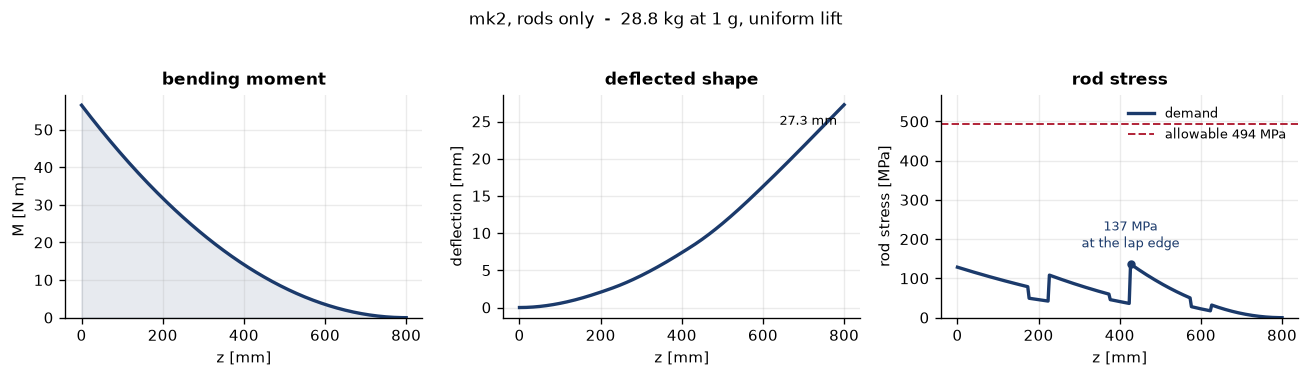

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.0))

ax[0].plot(zz, r1["M"] / 1000, color=ROD, lw=2)
ax[0].fill_between(zz, 0, r1["M"] / 1000, color=ROD, alpha=0.10)
ax[0].set(xlabel="z [mm]", ylabel="M [N m]", title="bending moment", ylim=(0, None))

ax[1].plot(zz, r1["delta"], color=ROD, lw=2)
ax[1].set(xlabel="z [mm]", ylabel="deflection [mm]", title="deflected shape")
ax[1].annotate(f"{r1['delta'][-1]:.1f} mm", (zz[-1], r1["delta"][-1]),
               textcoords="offset points", xytext=(-4, -12), ha="right", fontsize=8)

ax[2].plot(zz, r1["sigma"], color=ROD, lw=2, label="demand")
ax[2].axhline(rods.sigma_c, color=WARN, lw=1.2, ls="--",
              label=f"allowable {rods.sigma_c:.0f} MPa")
ax[2].plot(z_peak, r1["sigma"].max(), "o", color=ROD, ms=4)
ax[2].annotate(f"{r1['sigma'].max():.0f} MPa\nat the lap edge", (z_peak, r1["sigma"].max()),
               fontsize=8, color=ROD, ha="center", textcoords="offset points", xytext=(0, 10))
ax[2].set(xlabel="z [mm]", ylabel="rod stress [MPa]", title="rod stress",
          ylim=(0, rods.sigma_c * 1.15))
ax[2].legend(frameon=False, fontsize=8, loc="upper right")

fig.suptitle(f"mk2, rods only  -  {MASS_KG:.1f} kg at {N_G:.0f} g, {LIFT} lift", fontsize=10, y=1.03)
fig.tight_layout(); plt.show()

The **sawtooth** is the same effect as the $EI$ steps. Rod area drops at each lap edge while the
moment has barely moved, so the stress jumps by the area ratio. Under this distributed load the
peak is only 6 % above the root — the ladder is well matched to the load — but it is still at a lap
edge, not at the root.

The same panel and the same uniform load, swept over load factor.

In [14]:
G_CASES = [1.0, 3.0, 5.0]
runs = {ng: solve(panel, rods, mass_kg=MASS_KG, n=ng, lift="uniform") for ng in G_CASES}

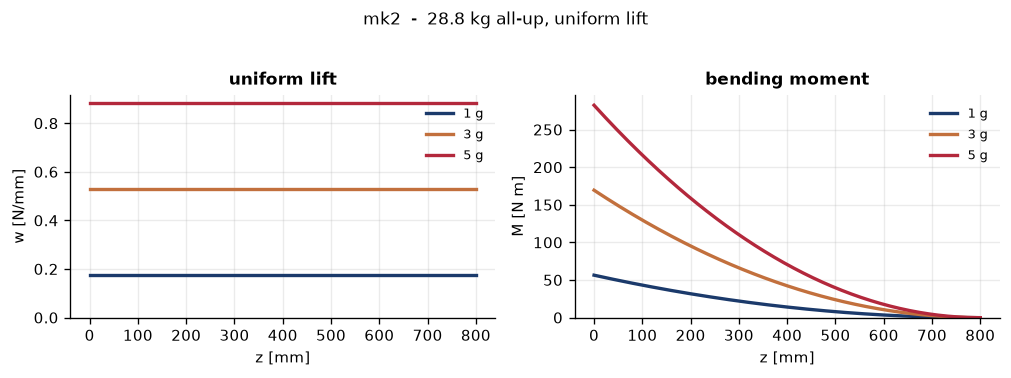

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.0))
shades = [ROD, MED, WARN]

for (ng, r), c in zip(runs.items(), shades):
    lab = f"{ng:.0f} g"
    ax[0].plot(r["z"], r["w"], color=c, lw=2, label=lab)
    ax[1].plot(r["z"], r["M"] / 1000, color=c, lw=2, label=lab)

ax[0].set(xlabel="z [mm]", ylabel="w [N/mm]", title="uniform lift", ylim=(0, None))
ax[1].set(xlabel="z [mm]", ylabel="M [N m]", title="bending moment", ylim=(0, None))
for a in ax:
    a.legend(frameon=False, fontsize=8, loc="upper right")

fig.suptitle(f"mk2  -  {MASS_KG:.1f} kg all-up, uniform lift", fontsize=10, y=1.03)
fig.tight_layout(); plt.show()

## 6. How much load does it carry?

The model is linear, so capacity is one division. The useful way to write it is as a **moment
capacity**, one curve belonging to the section and to no particular load case:

$$ M_{allow}(z) = \frac{\sigma_{allow}\,EI(z)}{E\,\mathrm{arm}(z)}
   = \sigma_{allow}\,\frac{A\sum_i (y_i-y_{na})^2}{\mathrm{arm}(z)} $$

| symbol | what it is | units |
|---|---|---|
| $\sigma_{allow}$ | working allowable stress in compression, 494 MPa (§3) | MPa |
| $\mathrm{arm}(z)$ | distance from the neutral axis to the furthest rod present at $z$ | mm |
| $M_{allow}(z)$ | the largest moment station $z$ can take before that furthest rod reaches $\sigma_{allow}$ | N·mm |

It is §3's $\sigma = M\,\mathrm{arm}/I$ solved for $M$. $E$ cancels, because $EI/E$ is just the
rods' $I$: strength depends on geometry and the allowable, not on how stiff the carbon is.

Any load case is then checked as $\min_z M_{allow}(z)/M(z)$. That ratio is the **factor the whole
load case can be multiplied by** before the first rod anywhere on the span reaches its allowable.
A factor of 3.6 on a 1 g case means the panel takes 3.6 g. The station where the minimum falls
tells you which part of the wing is holding it back.

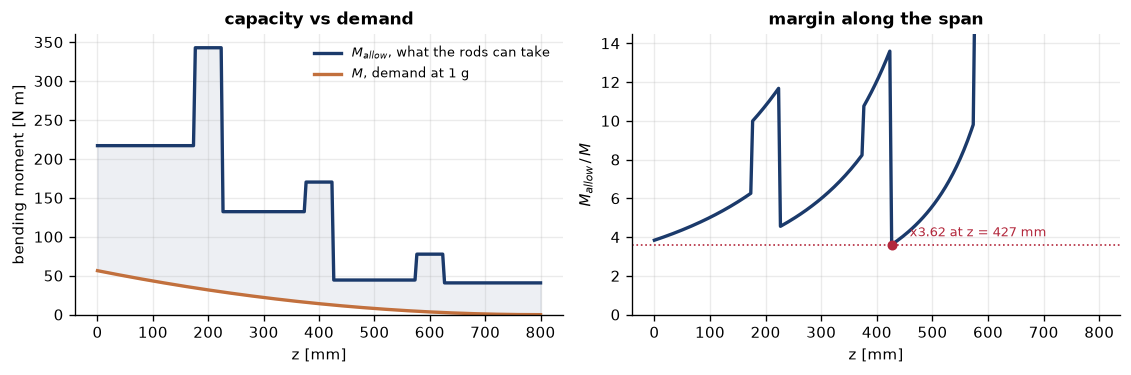

In [16]:
def capacity(panel, rods, res, sigma_allow=None):
    """Moment capacity along the span, and the factor this load case can be scaled by."""
    sa = rods.sigma_c if sigma_allow is None else sigma_allow
    M_allow = sa * res["EI"] / (rods.E * res["arm"])          # N.mm - E cancels internally
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(np.abs(res["M"]) > 1e-9, M_allow / np.abs(res["M"]), np.inf)
    k = int(np.argmin(ratio))
    return dict(M_allow=M_allow, ratio=ratio, k=k, factor=float(ratio[k]),
                z_crit=float(res["z"][k]))


cap = capacity(panel, rods, r1)
where = "the root" if cap["z_crit"] < 20 else "a lap edge, where the rod count steps down"

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.2))

ax[0].plot(zz, cap["M_allow"] / 1000, color=ROD, lw=2, label="$M_{allow}$, what the rods can take")
ax[0].plot(zz, r1["M"] / 1000, color=MED, lw=2, label=f"$M$, demand at {N_G:.0f} g")
ax[0].fill_between(zz, r1["M"] / 1000, cap["M_allow"] / 1000, color=ROD, alpha=0.08)
ax[0].set(xlabel="z [mm]", ylabel="bending moment [N m]", title="capacity vs demand",
          ylim=(0, None))
ax[0].legend(frameon=False, fontsize=8, loc="upper right")

finite = cap["ratio"][np.isfinite(cap["ratio"])]
ax[1].plot(zz, cap["ratio"], color=ROD, lw=2)
ax[1].axhline(cap["factor"], color=WARN, lw=1.0, ls=":")
ax[1].plot(cap["z_crit"], cap["factor"], "o", color=WARN, ms=5)
ax[1].annotate(f"  x{cap['factor']:.2f} at z = {cap['z_crit']:.0f} mm",
               (cap["z_crit"], cap["factor"]), fontsize=8, color=WARN,
               textcoords="offset points", xytext=(6, 5))
ax[1].set(xlabel="z [mm]", ylabel="$M_{allow}\\,/\\,M$", title="margin along the span",
          ylim=(0, min(finite.max(), cap["factor"] * 4)))

fig.tight_layout(); plt.show()


In [17]:
cases = (("distributed, elliptical", dict(mass_kg=MASS_KG, lift="elliptical")),
         ("distributed, uniform",    dict(mass_kg=MASS_KG, lift="uniform")),
         ("point load at the tip",   dict(tip_kg=1.0)))

hdr = f"{'load case':<25}{'capacity':>34}{'crit z':>10}{'tip deflection there':>24}"
print(hdr); print("-" * len(hdr))
for tag, kw in cases:
    r = solve(panel, rods, n=1.0, **kw)
    c = capacity(panel, rods, r)
    what = (f"{c['factor']:.1f} kgf hung on the tip" if r["P"] > 0
            else f"{c['factor']:.2f} g   = {c['factor']*MASS_KG:.0f} kg all-up at 1 g")
    d_lim = c["factor"] * r["delta"][-1]
    pct = f"({100*d_lim/panel.span:.0f} % of semi-span)"
    print(f"{tag:<25}{what:>34}{c['z_crit']:>8.0f} mm{d_lim:>7.0f} mm {pct:>16}")

load case                                          capacity    crit z    tip deflection there
---------------------------------------------------------------------------------------------
distributed, elliptical     4.53 g   = 130 kg all-up at 1 g       0 mm     90 mm (11 % of semi-span)
distributed, uniform        3.62 g   = 104 kg all-up at 1 g     427 mm     99 mm (12 % of semi-span)
point load at the tip              12.1 kgf hung on the tip     427 mm     75 mm (9 % of semi-span)


For this case:

**The root and the governing lap edge are nearly tied** — ×3.84 at the root against ×3.62 out at
z = 427 mm. A 6 % spread means the rod ladder is well spent: the carbon is worked about equally
hard at both ends. 
